# **ME 575 - Assignment #6 Gradient-Free Optimization**

In [31]:
# Code stuff
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import pandas as pd

**6.1** Implement your own version of the Nelder-Mead and apply your algorithm to the Egg Carton Problem. Report your results with a contour plot and a convergence plot.  

"Egg Carton" Equation
$$
f(x) = 0.1x_1^2 + 0.1x_2^2 - \cos(3x_1) - \cos(3x_2)
$$

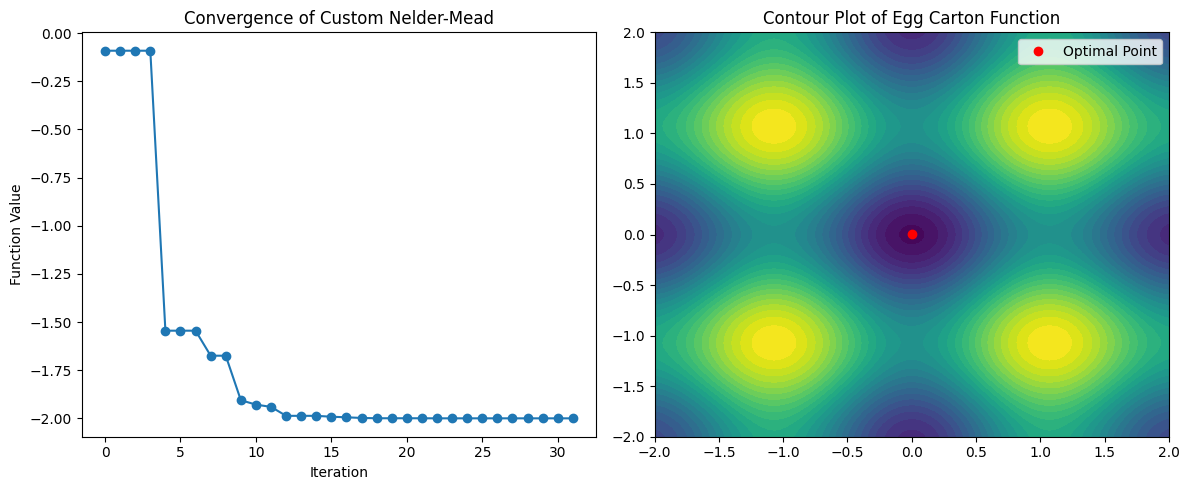

Optimal Point: [-6.96544114e-05  4.62429453e-04], Function Value: -1.9999989940135703

--- Scipy Nelder-Mead ---
Optimal Point: [1.04338169e-05 2.85224212e-05], Function Value: -1.9999999957569918


In [13]:
# 1. Egg Carton Objective Function
def egg_carton(x):
    x1, x2 = x[0], x[1]
    return 0.1*x1**2 + 0.1*x2**2 - np.cos(3*x1) - np.cos(3*x2)

# 2. Adapted Custom Nelder-Mead
def custom_nelder_mead(func, x0, l=1.5, alpha=1.0, gamma=2.0, rho=0.5, sigma=0.5, max_iter=100, tol=1e-6):
    n = len(x0)
    t1 = (l / (n * np.sqrt(2))) * (np.sqrt(n + 1) - 1)
    t2 = l / np.sqrt(2)
    simplex = [np.array(x0, dtype=float)]
    for i in range(n):
        s_i = np.full(n, t1); s_i[i] += t2
        simplex.append(x0 + s_i)
    
    simplex = np.array(simplex)
    history = []
    func_calls = 0

    for it in range(max_iter):
        res = np.array([func(x) for x in simplex])
        func_calls += len(simplex)
        idx = np.argsort(res)
        simplex, res = simplex[idx], res[idx]
        
        x_c = np.mean(simplex[:-1], axis=0)
        x_r = x_c + alpha * (x_c - simplex[-1])
        f_r = func(x_r)
        func_calls += 1
        
        move, target_pt = "", None
        
        if res[0] <= f_r < res[-2]:
            simplex[-1] = x_r
        elif f_r < res[0]:
            x_e = x_c + gamma * (x_c - simplex[-1])
            f_e = func(x_e)
            func_calls += 1
            if f_e < f_r:
                simplex[-1] = x_e
            else:
                simplex[-1] = x_r
        else:
            if f_r < res[-1]:
                x_oc = x_c + rho * (x_c - simplex[-1])
                func_calls += 1
                if func(x_oc) <= f_r:
                    simplex[-1] = x_oc
                else:
                    simplex[1:] = simplex[0] + sigma * (simplex[1:] - simplex[0])
            else:
                x_ic = x_c - rho * (x_c - simplex[-1])
                func_calls += 1
                if func(x_ic) < res[-1]:
                    simplex[-1] = x_ic
                else:
                    simplex[1:] = simplex[0] + sigma * (simplex[1:] - simplex[0])

        history.append({'best_val': res[0], 'best_pt': simplex[0].copy()})
        if np.std(res) < tol: 
            break
            
    return simplex[0], history, func_calls

# --- 6.1 Plots ---
best_pt, history, _ = custom_nelder_mead(egg_carton, [0.5, 0.5])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot([h['best_val'] for h in history], marker='o')
plt.title('Convergence of Custom Nelder-Mead')
plt.xlabel('Iteration')
plt.ylabel('Function Value')

plt.subplot(1, 2, 2)
x_val = np.linspace(-2, 2, 100)
y_val = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x_val, y_val)
Z = 0.1*X**2 + 0.1*Y**2 - np.cos(3*X) - np.cos(3*Y)
plt.contourf(X, Y, Z, levels=30, cmap='viridis')
plt.plot(best_pt[0], best_pt[1], 'ro', label='Optimal Point')
plt.title('Contour Plot of Egg Carton Function')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal Point: {best_pt}, Function Value: {egg_carton(best_pt)}")

# Scipy Comparison scipy.minimize
print("\n--- Scipy Nelder-Mead ---")
scipy_result = minimize(egg_carton, [0.5, 0.5], method='Nelder-Mead')
print(f"Optimal Point: {scipy_result.x}, Function Value: {scipy_result.fun}")


**6.2** Find an existing optimizer that performs Nelder-Mead and compare it to your Nelder-Mead implementation. Start from five different guesses (but the same initial guess to properly compare both your and the existing optimizer) and report the difference in function calls that were used in a table or other figure. Use the same convergence criterion to make it fair.

In [14]:
guesses = [[1, 1], [-2, 2], [0, -3], [4, 4], [-1, -1]]
results = []

for pt in guesses:
    _, _, calls_custom = custom_nelder_mead(egg_carton, pt)
    res_scipy = minimize(egg_carton, pt, method='Nelder-Mead', tol=1e-6)
    results.append({"Initial Guess": pt, "Custom Calls": calls_custom, "Scipy Calls": res_scipy.nfev})

df_comparison = pd.DataFrame(results)
display(df_comparison)

,Initial Guess,Custom Calls,Scipy Calls
0,"[1, 1]",129,107
1,"[-2, 2]",126,77
2,"[0, -3]",141,83
3,"[4, 4]",131,84
4,"[-1, -1]",125,107


**6.3**  Implement your own version of a Genetic Algorithm OR Particle Swarm and apply your algorithm to the Egg Carton Problem above. Explore the influence of population size, number of iterations/generations, convergence criteria, and the various parameters in your method: (e.g. crossover, mutation, inertia, damping, etc.) You should explore three difference variations and report on the influence of those variations. (i.e. population of 100 vs population of 200, mutation of 0.05 vs 0.01, etc.)

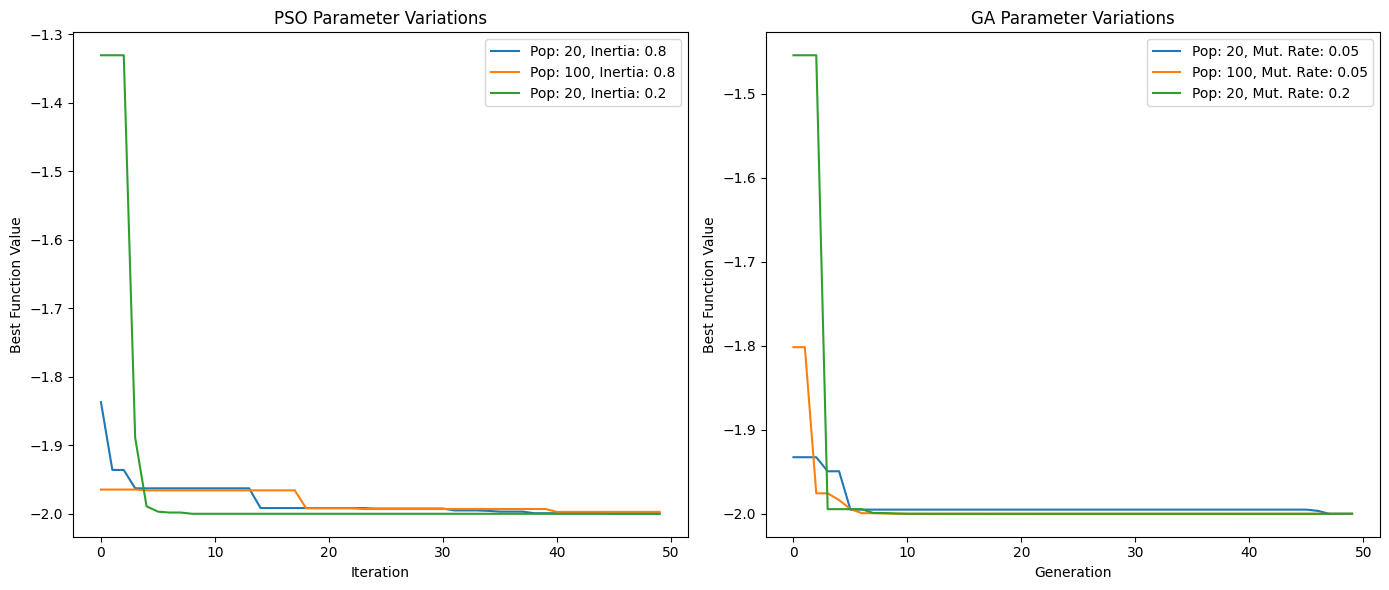

In [37]:
def egg_carton(x):
    x1, x2 = x[0], x[1]
    return 0.1*x1**2 + 0.1*x2**2 - np.cos(3*x1) - np.cos(3*x2)

# --- 1. Particle Swarm Optimization (PSO) ---
def particle_swarm_optimize(func, pop_size=30, iterations=50, w=0.5, c1=1.5, c2=1.5):
    particles = np.random.uniform(-5, 5, (pop_size, 2))
    velocities = np.zeros((pop_size, 2))
    pbest = particles.copy()
    pbest_obj = np.array([func(p) for p in pbest])
    gbest = pbest[np.argmin(pbest_obj)]
    gbest_obj = min(pbest_obj)
    
    history = []
    for _ in range(iterations):
        for i in range(pop_size):
            r1, r2 = np.random.rand(2)
            velocities[i] = w*velocities[i] + c1*r1*(pbest[i]-particles[i]) + c2*r2*(gbest-particles[i])
            particles[i] += velocities[i]
            
            # Keep within bounds
            particles[i] = np.clip(particles[i], -5, 5)
            
            obj = func(particles[i])
            if obj < pbest_obj[i]:
                pbest[i] = particles[i]
                pbest_obj[i] = obj
                if obj < gbest_obj:
                    gbest = particles[i]
                    gbest_obj = obj
        history.append(gbest_obj)
    return gbest, history

# --- 2. Continuous Genetic Algorithm (GA) ---
def genetic_algorithm_optimize(func, pop_size=30, generations=50, mutation_rate=0.1, crossover_rate=0.8):
    pop = np.random.uniform(-5, 5, (pop_size, 2))
    history = []
    
    for _ in range(generations):
        fitness = np.array([func(ind) for ind in pop])
        
        # Track best individual
        best_idx = np.argmin(fitness)
        history.append(fitness[best_idx])
        best_ind = pop[best_idx].copy()
        
        new_pop = []
        for _ in range(pop_size):
            # Tournament Selection
            i, j = np.random.randint(0, pop_size, 2)
            parent1 = pop[i] if fitness[i] < fitness[j] else pop[j]
            i, j = np.random.randint(0, pop_size, 2)
            parent2 = pop[i] if fitness[i] < fitness[j] else pop[j]
            
            # Arithmetic Crossover
            if np.random.rand() < crossover_rate:
                alpha = np.random.rand()
                child = alpha * parent1 + (1 - alpha) * parent2
            else:
                child = parent1.copy()
                
            # Gaussian Mutation
            if np.random.rand() < mutation_rate:
                child += np.random.normal(0, 0.5, 2)
                
            # Keep within bounds
            child = np.clip(child, -5, 5)
            new_pop.append(child)
            
        pop = np.array(new_pop)
        pop[0] = best_ind  # Elitism: carry over the best individual
        
    return best_ind, history

# --- 4. Exploring Variations ---
pso_variations = [
    {'pop_size': 20, 'w': 0.8},   # Base PSO
    {'pop_size': 100, 'w': 0.8},  # Higher population PSO
    {'pop_size': 20, 'w': 0.2}    # Lower inertia PSO
]

ga_variations = [
    {'pop_size': 20, 'mutation_rate': 0.05},  # Base GA
    {'pop_size': 100, 'mutation_rate': 0.05}, # Higher population GA
    {'pop_size': 20, 'mutation_rate': 0.20}   # Higher mutation GA
]

# Run Variations and Plot
plt.figure(figsize=(14, 6))

# Plot PSO Results
plt.subplot(1, 2, 1)
for var in pso_variations:
    _, hist = particle_swarm_optimize(egg_carton, **var)
    plt.plot(hist, label=f"Pop: {var['pop_size']}, Inertia: {var['w']}")
plt.title("PSO Parameter Variations")
plt.xlabel("Iteration")
plt.ylabel("Best Function Value")
plt.legend()

# Plot GA Results
plt.subplot(1, 2, 2)
for var in ga_variations:
    _, hist = genetic_algorithm_optimize(egg_carton, **var)
    plt.plot(hist, label=f"Pop: {var['pop_size']}, Mut. Rate: {var['mutation_rate']}")
plt.title("GA Parameter Variations")
plt.xlabel("Generation")
plt.ylabel("Best Function Value")
plt.legend()

plt.tight_layout()
plt.show()

**6.4** Apply your own gradient-free method to your project (or a simplified version of your project’s objective function or at least inspired by your project). You can simplify as needed but need to have at least two design variables. If it would still be too complex, apply your method to a simpler test problem (that is, not the Egg Carton) from one of the options from HW#5. Include appropriate figures to demonstrate your implementation. Also, describe your project’s goal and objective function to help orient the grader to what they are seeing.

In [ ]:
# Function to optimize: Ackley Function 
def ackley(x):
    x1, x2 = x[0], x[1]
    term1 = -20 * np.exp(-0.2 * np.sqrt(0.5 * (x1**2 + x2**2)))
    term2 = -np.exp(0.5 * (np.cos(2 * np.pi * x1) + np.cos(2 * np.pi * x2)))
    return term1 + term2 + np.e + 20